<a href="https://colab.research.google.com/github/dimkpapadopoulos/machine-learning-projects/blob/main/Multi_class_Dog_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Multi-class classification is a whole different beast to defeat compared to binary classification. Here we explore a much larger dataset with 10000 samples of dog images, with a total of 120 classes (breeds).


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

# deep learning libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import applications
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
import cv2

import warnings
warnings.filterwarnings('ignore')

In [ ]:
!unzip /content/drive/MyDrive/dog-breed-identification.zip -d /content/dog

In [ ]:
labels = pd.read_csv("/content/dog/labels.csv")

train_path = "/content/dog/train"
test_path = "/content/dog/test"
labels.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


Here is the distribution of samples across the entire dataset.

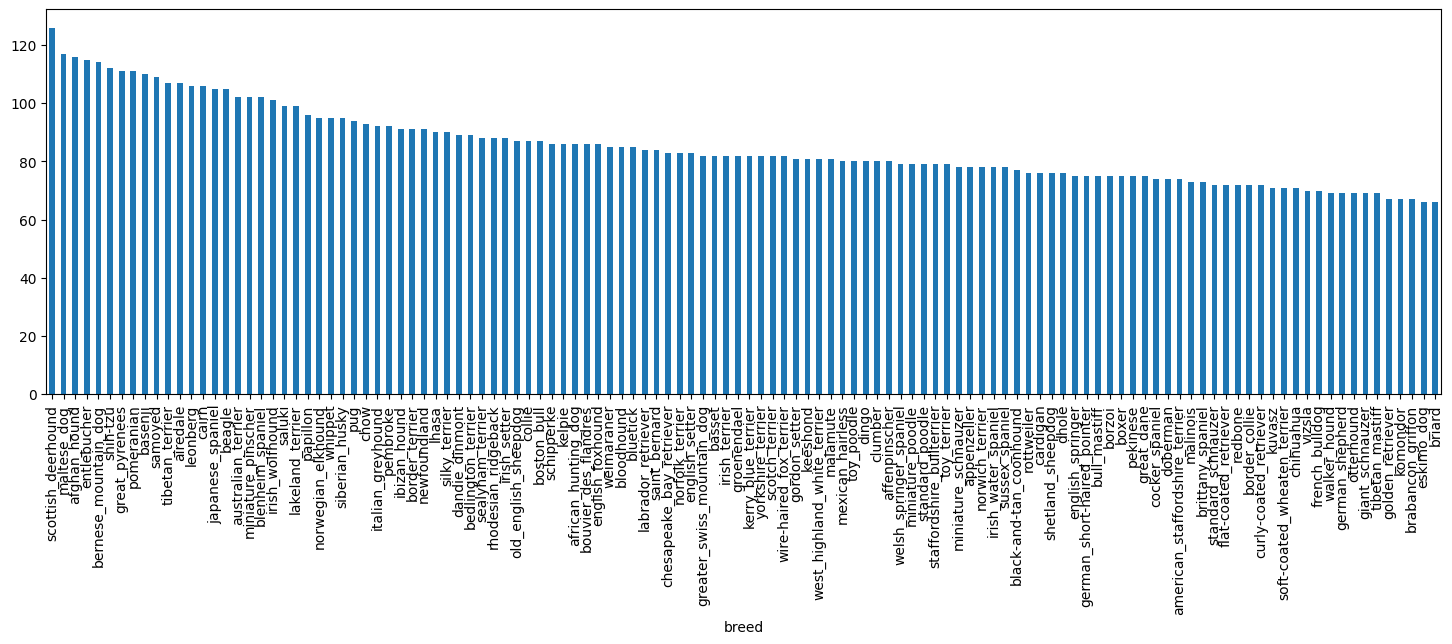

In [ ]:
plt.figure(figsize=(18, 5))
labels['breed'].value_counts().plot.bar()

plt.show()

In [ ]:
# match the id from the .csv file to the actual image file
def to_jpg(id):
    return id+".jpg"

labels['id'] = labels['id'].apply(to_jpg)

In [ ]:
# Data augmentation and pre-processing using tensorflow
TARGET_SIZE = (299, 299)
gen = ImageDataGenerator(
                  rescale=1./255.,
                  horizontal_flip = True,
                  validation_split=0.2 # training: 80% data, validation: 20% data
                 )

train_generator = gen.flow_from_dataframe(
    labels, # dataframe
    directory = train_path, # images data path / folder in which images are in
    x_col = 'id',
    y_col = 'breed',
    subset="training",
    color_mode="rgb",
    target_size = TARGET_SIZE, # image height , image width
    class_mode="categorical",
    batch_size=64,
    shuffle=True,
    seed=42,
)


validation_generator = gen.flow_from_dataframe(
    labels, # dataframe
    directory = train_path, # images data path / folder in which images are in
    x_col = 'id',
    y_col = 'breed',
    subset="validation",
    color_mode="rgb",
    target_size = TARGET_SIZE, # image height , image width
    class_mode="categorical",
    batch_size=64,
    shuffle=True,
    seed=42,
)

Found 8178 validated image filenames belonging to 120 classes.
Found 2044 validated image filenames belonging to 120 classes.


25 examples of images in the dataset.

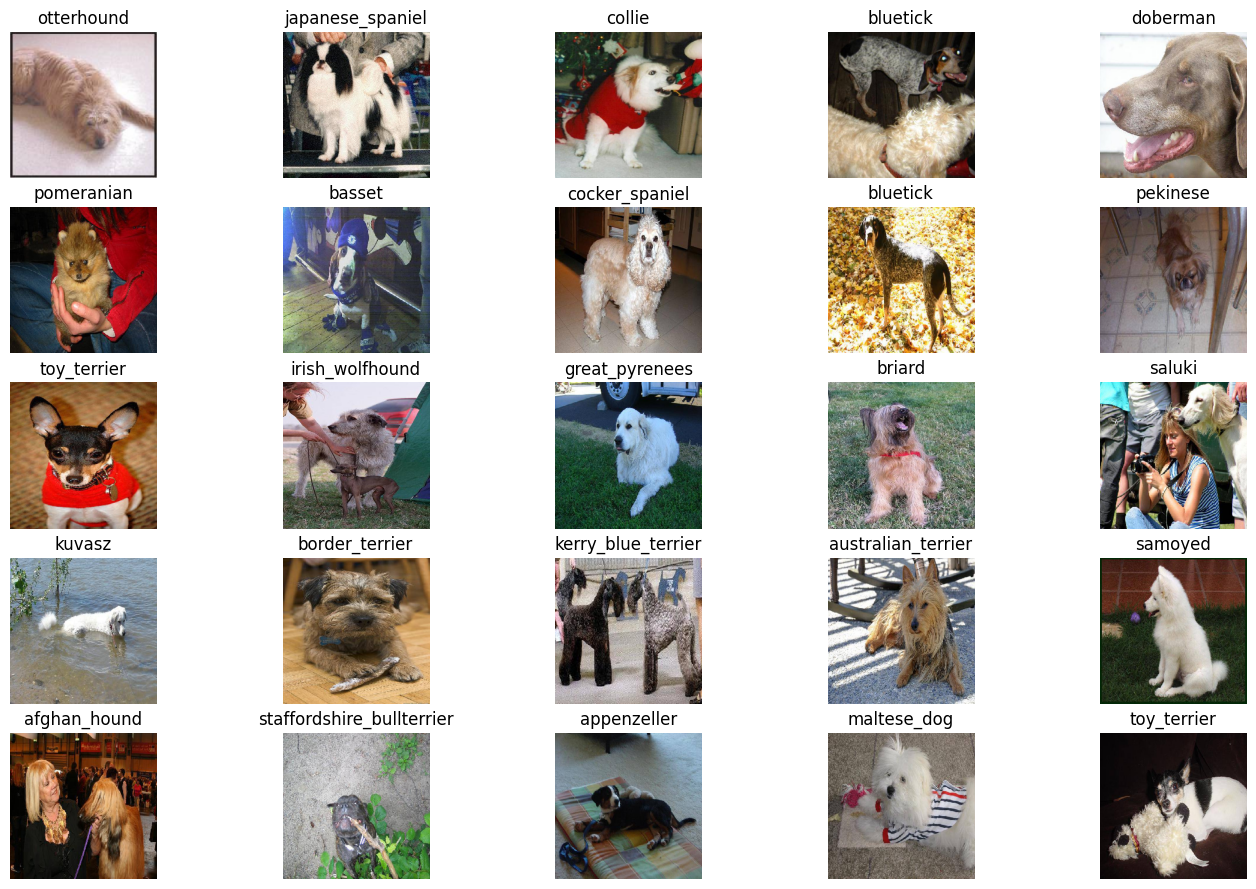

In [ ]:
a = train_generator.class_indices
class_names = list(a.keys())  # storing class/breed names in a list


def plot_images(img, labels):
    plt.figure(figsize=[17, 11])
    for i in range(25):
        plt.subplot(5, 5, i+1)
        plt.imshow(img[i])
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis('off')

x,y = next(train_generator)
plot_images(x,y)

We will utilize pre-trained model weights for this classification task. Specifically, the Xception model, trained on the ImageNet dataset. Xception is a deep convolutional neural network with 20 million parameters. To fully leverage the robust training of this model, we exclude this parameters from the training process. This is called Transfer Learning. Xception will act as our feature extractor. Then, we attach a dense layer to that, after performing Global Average Pooling instead of just flattening the output. A very large Dropout of 50%, to avoid overfitting. In order to fit a larger batch size, we use mixed precision training, where instead of training with the full 32 bit float, some weights are dynamically assigned in 16 bit float with minimal accuracy loss. The output layer of the neural network is explicitly set to 32 bit for increased accuracy.

In [ ]:
# load the Xception architecture with imagenet weights as base
base_model = tf.keras.applications.Xception(
                     include_top=False,
                     weights='imagenet',
                     input_shape=(299,299,3)
                     )

base_model.trainable=False

# Build the model and pass an input with a defined shape
# so the model can infer the shapes of all the layers
input_tensor = tf.keras.Input(shape=(299,299,3))
output_tensor = base_model(input_tensor)

# Now build the rest of your model
model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(120, activation='softmax', dtype='float32')
    ])
optim = tf.keras.optimizers.Adam(learning_rate=2e-4)
model.compile(optimizer=optim,loss='categorical_crossentropy',metrics=['accuracy'])

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 120)            │        61,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,980,320 (83.85 MB)

 Trainable params: 1,114,744 (4.25 MB)

 Non-trainable params: 20,865,576 (79.60 MB)

In [ ]:
early = tf.keras.callbacks.EarlyStopping( patience=10,
                                          min_delta=0.001,
                                          restore_best_weights=True)

In [ ]:
batch_size=64

history = model.fit(train_generator,
                    validation_data=validation_generator,
                    epochs=25,
                    callbacks=[early])

Epoch 1/25
128/128 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.5674 - loss: 1.9581 - val_accuracy: 0.8625 - val_loss: 2.3400
Epoch 2/25
128/128 ━━━━━━━━━━━━━━━━━━━━ 45s 352ms/step - accuracy: 0.8447 - loss: 0.5768 - val_accuracy: 0.8772 - val_loss: 0.8479
Epoch 3/25
128/128 ━━━━━━━━━━━━━━━━━━━━ 45s 350ms/step - accuracy: 0.8715 - loss: 0.4388 - val_accuracy: 0.8811 - val_loss: 0.4402
Epoch 4/25
128/128 ━━━━━━━━━━━━━━━━━━━━ 45s 350ms/step - accuracy: 0.8890 - loss: 0.3634 - val_accuracy: 0.8821 - val_loss: 0.3850
Epoch 5/25
128/128 ━━━━━━━━━━━━━━━━━━━━ 45s 351ms/step - accuracy: 0.8991 - loss: 0.3112 - val_accuracy: 0.8845 - val_loss: 0.3920
Epoch 6/25
128/128 ━━━━━━━━━━━━━━━━━━━━ 47s 367ms/step - accuracy: 0.9128 - loss: 0.2770 - val_accuracy: 0.8821 - val_loss: 0.3922
Epoch 7/25
128/128 ━━━━━━━━━━━━━━━━━━━━ 46s 354ms/step - accuracy: 0.9261 - loss: 0.2366 - val_accuracy: 0.8855 - val_loss: 0.3820
Epoch 8/25
128/128 ━━━━━━━━━━━━━━━━━━━━ 45s 353ms/step - accuracy: 0.9315 - loss: 0.2

From the plots of accuracy and loss, we see that the model reaches 88% accuracy on the validation set, with 0.42 loss. Despite the heavy dropout, some overfitting is observed, from the training loss being much lower than the validation.

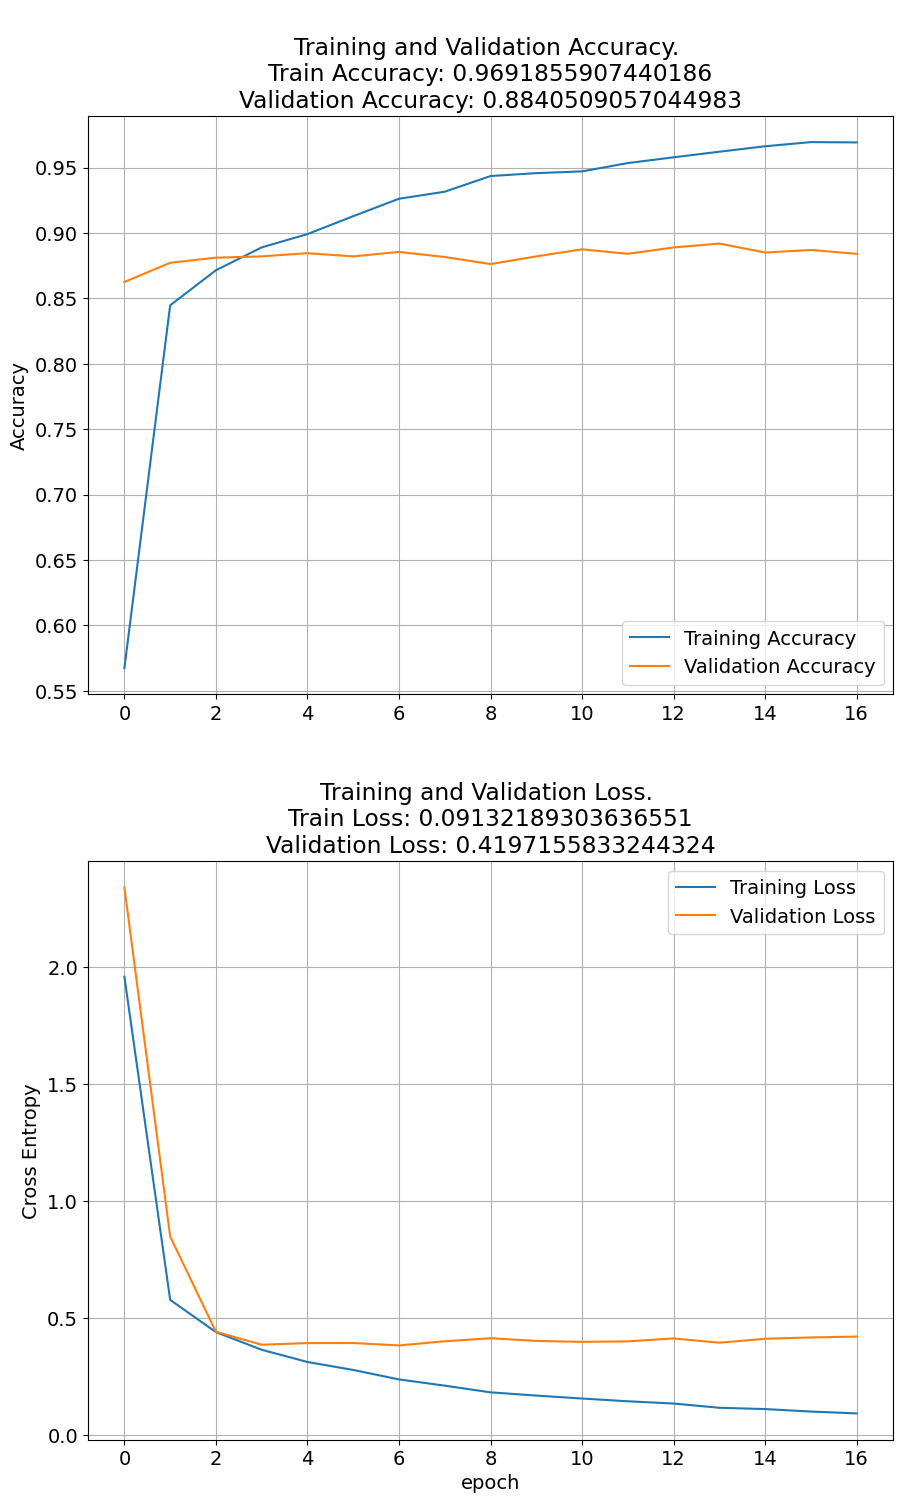

In [ ]:
# store results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']


# plot results
# accuracy
plt.figure(figsize=(10, 16))
plt.rcParams['figure.figsize'] = [16, 9]
plt.rcParams['font.size'] = 14
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.facecolor'] = 'white'
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.title(f'\nTraining and Validation Accuracy. \nTrain Accuracy: {str(acc[-1])}\nValidation Accuracy: {str(val_acc[-1])}')
# loss
plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.title(f'Training and Validation Loss. \nTrain Loss: {str(loss[-1])}\nValidation Loss: {str(val_loss[-1])}')
plt.xlabel('epoch')
plt.tight_layout(pad=3.0)
plt.show()